# MOSAIC Demonstration: 2D Chemical Ordering from Projected PMN Columns

This notebook mirrors the 2D PMN chemical-ordering example, but the input structure is **not** a single crystallographic slice. Instead it uses the `110` projected-column dataset from `examples/PMN/columns_pmn_pbc_general_110.csv`.

Key differences from the slice notebook:
- the CSV `X/Y/Xav/Yav` coordinates are in angstrom and are converted to **relative** `.f2d` coordinates before loading into MOSAIC
- the `.f2d` `coeff` column stores projected `Z_mean`, derived from the PMN CSV as `(41*Nb + 12*Mg)/Atom_Count`
- all sites use the same placeholder species label `El1`
- the projected lattice is rectangular, so plotting must use both projected lengths instead of the square-cell shortcut used by the slice example

In the current CSV axis order, the projected cell lengths are `a/sqrt(2)` along `X` and `a` along `Y`.


In [1]:
import os
import sys
import json
import re
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

MOSAIC_ROOT = Path(os.path.abspath('')).parent
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

os.environ['MOSAIC_SAVE_SCATTERING_INTERVAL_ARTIFACTS'] = '1'

EXAMPLE_DIR = Path('config_2D/chemical_ordering')
STRUCTURE_FILE = 'sample_2d_chem_PMN_proj_110.f2d'
OUTPUT_STEM = 'output_demo_pmn_proj110'

print(f'MOSAIC root : {MOSAIC_ROOT}')
print(f'Example dir : {EXAMPLE_DIR}')
print(f'Structure   : {STRUCTURE_FILE}')


MOSAIC root : <repo>
Example dir : config_2D/chemical_ordering
Structure   : sample_2d_chem_PMN_proj_110.f2d


## 1. Inspect the Projected Structure File

The generated `.f2d` file contains one point per projected column on a `40 x 40` grid. The 2D lattice parameters are reconstructed from the `110` projection, and the `coeff` field contains projected `Z_mean` values derived from the PMN column counts.

For plotting, use both projected lattice lengths explicitly:
- `a = 40 x 4.052137 A = 162.085480 A`
- `a/sqrt(2) = 40 x 2.8652936 A = 114.611742 A`


Supercell dimensions     : [40, 40]
Cell (Ang/deg)           : [114.611742, 162.08548, 90.0]
Projected lengths        : a/sqrt(2) = 114.611742 A, a = 162.085480 A
Number of points         : 1600
Coefficient min/max      : 20.700000 / 40.275000
Coefficient mean         : 31.334391
Coefficient std          : 3.026211

First 5 rows:
  El1 -0.0000000221 0.0003051524 0.0000000772 0.0003124803 1 32.300000000000
  El1 -0.0000039922 0.0259316480 0.0000000745 0.0259374820 1 33.750000000000
  El1 -0.0000016274 0.0515565473 0.0000000853 0.0515624752 1 25.775000000000
  El1 -0.0000029225 0.0771846352 0.0000000960 0.0771874685 1 32.300000000000
  El1 -0.0000019328 0.1028113893 0.0000000772 0.1028124803 1 28.675000000000


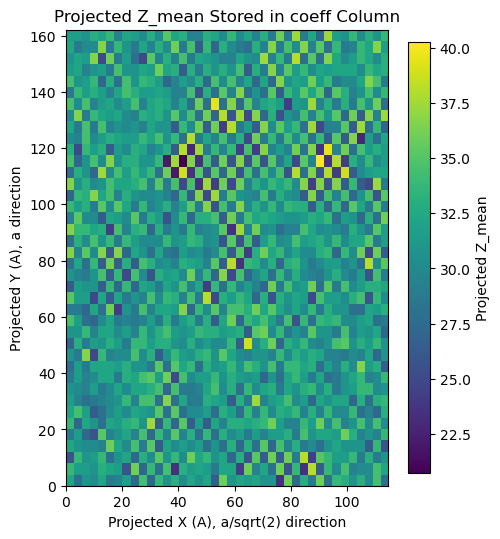

In [2]:
struct_path = EXAMPLE_DIR / STRUCTURE_FILE
with open(struct_path) as f:
    lines = f.readlines()

sc_match = re.search(r'Supercell dimensions:\s+(\d+)\s+(\d+)', lines[0])
supercell_dims = [int(sc_match.group(1)), int(sc_match.group(2))]
cell_params = [float(x) for x in re.findall(r'[\d.\-E]+', lines[1])]
proj_len_short = cell_params[0]   # a/sqrt(2) in the CSV X direction
proj_len_long = cell_params[1]    # a in the CSV Y direction

rows = []
for line in lines[3:]:
    parts = line.strip().split()
    rows.append((parts[0], float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4]), int(parts[5]), float(parts[6])))

records = np.array(rows, dtype=object)
coeffs = records[:, 6].astype(float)

print(f'Supercell dimensions     : {supercell_dims}')
print(f'Cell (Ang/deg)           : {cell_params}')
print(f'Projected lengths        : a/sqrt(2) = {proj_len_short:.6f} A, a = {proj_len_long:.6f} A')
print(f'Number of points         : {len(rows)}')
print(f'Coefficient min/max      : {coeffs.min():.6f} / {coeffs.max():.6f}')
print(f'Coefficient mean         : {coeffs.mean():.6f}')
print(f'Coefficient std          : {coeffs.std():.6f}')
print()
print('First 5 rows:')
for line in lines[3:8]:
    print(' ', line.strip())

coeff_grid = coeffs.reshape(supercell_dims)
fig, ax = plt.subplots(figsize=(5.2, 7.0))
im = ax.imshow(
    coeff_grid.T,
    origin='lower',
    cmap='viridis',
    extent=[0.0, proj_len_short, 0.0, proj_len_long],
    aspect='equal',
)
ax.set_title('Projected Z_mean Stored in coeff Column')
ax.set_xlabel('Projected X (A), a/sqrt(2) direction')
ax.set_ylabel('Projected Y (A), a direction')
fig.colorbar(im, ax=ax, shrink=0.8, label='Projected Z_mean')
plt.show()



## 2. Build the Same MOSAIC Configurations

The processing settings are the same as in the slice notebook, but the circular reciprocal-space filter is treated explicitly as a **signal-pass mask**:
- `mode: chemical`
- `method: from_average`
- coefficient centering by the global mean
- a circular **pass region** around half-integer reciprocal-space positions
- a complementary `rest` run containing everything outside that pass region

The projected pass-mask radius used here is `0.3178` r.l.u.


In [ ]:
MASK_RADIUS = 0.3178
MASK_EQ = f'(((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) <= ({MASK_RADIUS}**2.0))'
REST_EQ = f'(((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) > ({MASK_RADIUS}**2.0))'
PASS_ALL_EQ = 'h**2 + k**2 + 1 >= 0'


# The circular mask is a pass-region: signal inside the circles is kept.
def build_config(output_name: str, mask_equation: str):
    return {
        'schema_version': 2,
        'paths': {
            'config_root': str(EXAMPLE_DIR.resolve()),
            'structure_file': STRUCTURE_FILE,
            'output_directory': str((EXAMPLE_DIR / output_name).resolve()),
        },
        'structure': {
            'dimension': 2,
            'coefficients': {'source': 'config'},
        },
        'reciprocal_space': {
            'intervals': [{'limit': [40.0, 40.0], 'subvolume_step': [5.0, 5.0]}],
            'mask': {'equation': mask_equation},
        },
        'processing': {
            'mode': 'chemical',
            'method': 'from_average',
            'num_chunks': 1,
            'fresh_start': True,
            'run_postprocessing': True,
            'chemical_filtered_ordering': True,
            'coefficients': {'center_by': 'global', 'use': True},
            'points': [
                {
                    'selector': {'element': 'El1', 'reference_number': 1},
                    'window': {
                        'dist_from_atom_center': [0.2, 0.2],
                        'step_in_angstrom': [0.8125, 0.8125],
                    },
                }
            ],
        },
        'runtime': {
            'progress': {'force': True, 'task_logs': True},
            'dask': {
                'backend': 'local',
                'max_workers': 4,
                'threads_per_worker': 1,
                'processes': True,
                'worker_wait_timeout': '30s',
            },
            'scattering_weights': {'kind': 'ones', 'calculator': 'default'},
        },
    }

run_specs = [
    ('all', PASS_ALL_EQ),
    ('masked', MASK_EQ),
    ('rest', REST_EQ),
]

run_paths = {}
for suffix, mask_equation in run_specs:
    input_path = EXAMPLE_DIR / f'input_parameters_demo_pmn_proj110_{suffix}.json'
    run_path = EXAMPLE_DIR / f'run_parameters_demo_pmn_proj110_{suffix}.json'
    payload = build_config(f'{OUTPUT_STEM}_{suffix}', mask_equation)
    with open(input_path, 'w') as f:
        json.dump(payload, f, indent=2)
    with open(run_path, 'w') as f:
        json.dump({'input_parameters_path': str(input_path.resolve())}, f, indent=2)
    run_paths[suffix] = run_path
    print(f'Wrote {input_path.name} and {run_path.name}')
print(f'Pass-mask radius: {MASK_RADIUS:.4f} r.l.u.')


In [ ]:
from example_runner import run_mosaic_case

for suffix in ('all', 'masked', 'rest'):
    run_mosaic_case(run_paths[suffix], repo_root=MOSAIC_ROOT, tag=suffix)


## 3. Diffuse Scattering Intensity with Circular Pass Mask Overlay

The scattering amplitude in chemical mode is computed from the projected coefficient field using globally mean-centred coefficients, matching the slice workflow. The circular pass mask selects half-integer superstructure positions in reciprocal space, while the complementary `rest` output keeps everything outside that pass region.


In [ ]:
from matplotlib.colors import LogNorm


def load_interval_file(path):
    if path.suffix == ".hdf5":
        import h5py
        with h5py.File(path, "r") as h5:
            return h5["q_grid"][:], h5["q_amp"][:], h5["q_amp_av"][:]
    with np.load(path) as data:
        return data["q_grid"], data["q_amp"], data["q_amp_av"]


def load_interval_data(output_dir):
    """Load q_grid, q_amp, q_amp_av from interval HDF5 artifacts, with legacy NPZ fallback."""
    interval_dir = Path(output_dir) / "processed_point_data" / "precomputed_intervals"
    hdf5_files = sorted(interval_dir.glob("interval_*.hdf5"))
    npz_files = sorted(interval_dir.glob("interval_*.npz"))
    interval_files = hdf5_files if hdf5_files else npz_files
    if not interval_files:
        raise FileNotFoundError(
            f"No interval_*.hdf5 or interval_*.npz files found in {interval_dir}"
        )

    all_q_grid, all_q_amp, all_q_amp_av = [], [], []
    for interval_path in interval_files:
        q_grid_i, q_amp_i, q_amp_av_i = load_interval_file(interval_path)
        all_q_grid.append(q_grid_i)
        all_q_amp.append(q_amp_i)
        all_q_amp_av.append(q_amp_av_i)

    return (
        np.concatenate(all_q_grid, axis=0),
        np.concatenate(all_q_amp, axis=0),
        np.concatenate(all_q_amp_av, axis=0),
    )


def unique_sorted_tol(a, tol=1e-10):
    s = np.sort(np.asarray(a, dtype=float))
    if s.size == 0:
        return s
    out = [s[0]]
    for value in s[1:]:
        if abs(value - out[-1]) > tol:
            out.append(value)
    return np.array(out)


def nearest_index(vec, vals):
    vec = np.asarray(vec, dtype=float)
    vals = np.asarray(vals, dtype=float)
    j = np.searchsorted(vec, vals)
    j0 = np.clip(j - 1, 0, vec.size - 1)
    j1 = np.clip(j, 0, vec.size - 1)
    d0 = np.abs(vals - vec[j0])
    d1 = np.abs(vals - vec[j1])
    return np.where(d1 < d0, j1, j0)


def build_intensity_grid(q_grid, intensity, cell_params_2d, supercell_dims_2d):
    scales = np.array([
        cell_params_2d[0] / (supercell_dims_2d[0] * 2.0 * np.pi),
        cell_params_2d[1] / (supercell_dims_2d[1] * 2.0 * np.pi),
    ])
    q_hkl = q_grid[:, :2] * scales
    h, k = q_hkl[:, 0], q_hkl[:, 1]
    hv = unique_sorted_tol(h)
    kv = unique_sorted_tol(k)
    ih = nearest_index(hv, h)
    ik = nearest_index(kv, k)
    out = np.full((kv.size, hv.size), np.nan)
    out[ik, ih] = intensity
    return hv, kv, out


def make_circle_mask_grid(hv, kv, radius):
    hh, kk = np.meshgrid(hv, kv)
    dh = np.mod(hh, 1.0) - 0.5
    dk = np.mod(kk, 1.0) - 0.5
    return dh**2 + dk**2 <= radius**2


def positive_image(arr):
    out = np.array(arr, dtype=float, copy=True)
    out[~np.isfinite(out)] = np.nan
    out[out <= 0] = np.nan
    return out


def robust_log_limits(arr, lower_pct, upper_pct):
    vals = np.asarray(arr, dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return 1e-12, 1.0
    vmin = float(np.percentile(vals, lower_pct))
    vmax = float(np.percentile(vals, upper_pct))
    if not np.isfinite(vmin) or vmin <= 0:
        vmin = float(np.min(vals))
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = float(np.max(vals))
    if vmax <= vmin:
        vmax = vmin * 10.0
    return vmin, vmax


def load_site_contrast(output_dir):
    proc_dir = Path(output_dir) / 'processed_point_data'
    candidates = [
        proc_dir / 'chunk_0_site_contrast.csv',
        proc_dir / 'output_chunk_0_site_contrast.csv',
    ]
    for csv_path in candidates:
        if csv_path.exists():
            break
    else:
        raise FileNotFoundError(f'No site_contrast CSV found in {proc_dir}')

    ids, x_pos, y_pos, i_real, i_imag = [], [], [], [], []
    with open(csv_path) as f:
        reader = csv.DictReader(f, delimiter='	')
        for row in reader:
            ids.append(int(row['central_point_id']))
            x_pos.append(float(row['x']))
            y_pos.append(float(row['y']))
            i_real.append(float(row['intensity_real']))
            i_imag.append(float(row.get('intensity_imag', row.get('intensity_imaginary', 0.0))))
    ids = np.array(ids, dtype=int)
    order = np.argsort(ids)
    return (
        ids[order],
        np.array(x_pos, dtype=float)[order],
        np.array(y_pos, dtype=float)[order],
        np.array(i_real, dtype=float)[order],
        np.array(i_imag, dtype=float)[order],
    )


In [ ]:
output_all = EXAMPLE_DIR / f'{OUTPUT_STEM}_all'
q_grid, q_amp, q_amp_av = load_interval_data(output_all)

intensity_total = (q_amp * np.conj(q_amp)).real
intensity_diffuse = ((q_amp - q_amp_av) * np.conj(q_amp - q_amp_av)).real

hv, kv, I_total_2d = build_intensity_grid(q_grid, intensity_total, cell_params[:2], supercell_dims)
_, _, I_diffuse_2d = build_intensity_grid(q_grid, intensity_diffuse, cell_params[:2], supercell_dims)
circle_mask = make_circle_mask_grid(hv, kv, radius=MASK_RADIUS)

print(f'Q-grid shape   : {q_grid.shape}')
print(f'Intensity grid : ({len(kv)}, {len(hv)})')
print(f'h range        : [{hv.min():.3f}, {hv.max():.3f}]')
print(f'k range        : [{kv.min():.3f}, {kv.max():.3f}]')
print(f'Pass-mask coverage: {circle_mask.sum()}/{circle_mask.size} points ({100.0*circle_mask.sum()/circle_mask.size:.1f}%)')


In [ ]:
# --- Reciprocal-space plots: full range and zoomed window ---
I_total_log = positive_image(I_total_2d)
I_diffuse_log = positive_image(I_diffuse_2d)

vmin_tot, vmax_tot = robust_log_limits(I_total_log, 1.0, 99.5)
vmin_ds, vmax_ds = robust_log_limits(I_diffuse_log, 10.0, 99.8)

extent = [hv.min(), hv.max(), kv.min(), kv.max()]
mask_rgba = np.zeros((*circle_mask.shape, 4))
mask_rgba[circle_mask, :] = [0.0, 0.9, 1.0, 0.12]
alpha_grid = np.where(circle_mask, 1.0, 0.12)

cmap_total = plt.cm.inferno.copy()
cmap_total.set_bad('black')
cmap_diffuse = plt.cm.inferno.copy()
cmap_diffuse.set_bad('black')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
im0 = ax.imshow(I_total_log, origin='lower', extent=extent, cmap=cmap_total,
                aspect='equal', interpolation='bilinear',
                norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
fig.colorbar(im0, ax=ax, shrink=0.8, label='|A|^2')
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(a) Total Intensity  |A|^2')

ax = axes[1]
im1 = ax.imshow(I_diffuse_log, origin='lower', extent=extent, cmap=cmap_diffuse,
                aspect='equal', interpolation='bilinear',
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
ax.imshow(mask_rgba, origin='lower', extent=extent, aspect='equal', interpolation='nearest')
fig.colorbar(im1, ax=ax, shrink=0.8, label='|ΔA|^2')
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(b) Diffuse Scattering  |ΔA|^2 + Pass Mask')

ax = axes[2]
im2 = ax.imshow(I_diffuse_log, origin='lower', extent=extent, cmap=cmap_diffuse,
                aspect='equal', interpolation='bilinear',
                norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
im2.set_alpha(alpha_grid)
fig.colorbar(im2, ax=ax, shrink=0.8, label='|ΔA|^2')
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(c) Diffuse Scattering (mask-emphasized)')
ax.set_facecolor('black')

fig.suptitle('Projected PMN: reciprocal-space scattering and circular pass mask (full range)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

HKL_LIM = 3
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes2[0]
im = ax.imshow(I_total_log, origin='lower', extent=extent, cmap=cmap_total,
               aspect='equal', interpolation='bilinear',
               norm=LogNorm(vmin=vmin_tot, vmax=vmax_tot))
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(a) Total Intensity  |A|^2')
fig2.colorbar(im, ax=ax, shrink=0.8, label='|A|^2')

ax = axes2[1]
im = ax.imshow(I_diffuse_log, origin='lower', extent=extent, cmap=cmap_diffuse,
               aspect='equal', interpolation='bilinear',
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
ax.imshow(mask_rgba, origin='lower', extent=extent, aspect='equal', interpolation='nearest')
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(b) Diffuse Scattering  |ΔA|^2 + Pass Mask')
fig2.colorbar(im, ax=ax, shrink=0.8, label='|ΔA|^2')

ax = axes2[2]
im = ax.imshow(I_diffuse_log, origin='lower', extent=extent, cmap=cmap_diffuse,
               aspect='equal', interpolation='bilinear',
               norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
im.set_alpha(alpha_grid)
ax.set_facecolor('black')
ax.set_xlim(-HKL_LIM, HKL_LIM)
ax.set_ylim(-HKL_LIM, HKL_LIM)
ax.set_xlabel('h (r.l.u.)')
ax.set_ylabel('k (r.l.u.)')
ax.set_title('(c) Diffuse Scattering (mask-emphasized)')
fig2.colorbar(im, ax=ax, shrink=0.8, label='|ΔA|^2')

fig2.suptitle('Projected PMN: reciprocal-space scattering and circular pass mask (h,k in [-3,3])', fontsize=14, y=1.02)
fig2.tight_layout()
plt.show()


## 4. Zoomed Views: Pass Mask around Superstructure Reflections

These insets mirror the slice notebooks and show how the circular pass mask samples the diffuse superstructure signal near key half-integer reflections.


In [ ]:
# --- Zoomed insets around specific superstructure reflections ---
zooms = [
    {'center': (0.5, 0.5), 'half': 0.8, 'label': r'$\frac{1}{2}\frac{1}{2}$ reflection'},
    {'center': (1.5, 0.5), 'half': 0.8, 'label': r'$\frac{3}{2}\frac{1}{2}$ reflection'},
    {'center': (1.5, 1.5), 'half': 0.8, 'label': r'$\frac{3}{2}\frac{3}{2}$ reflection'},
]

fig, axes = plt.subplots(1, len(zooms), figsize=(5.5 * len(zooms), 5))
if len(zooms) == 1:
    axes = [axes]

for ax, z in zip(axes, zooms):
    cx, cy = z['center']
    hw = z['half']
    im = ax.imshow(I_diffuse_log, origin='lower', extent=extent, cmap=cmap_diffuse,
                   aspect='equal', interpolation='bilinear',
                   norm=LogNorm(vmin=vmin_ds, vmax=vmax_ds))
    ax.imshow(mask_rgba, origin='lower', extent=extent, aspect='equal', interpolation='nearest')
    ax.set_xlim(cx - hw, cx + hw)
    ax.set_ylim(cy - hw, cy + hw)
    ax.set_xlabel('h (r.l.u.)')
    ax.set_ylabel('k (r.l.u.)')
    ax.set_title(z['label'])

fig.suptitle('Zoomed: circular pass mask around superstructure reflections', fontsize=13)
fig.tight_layout()
plt.show()


## 5. Load and Compare Chemical Ordering Fields

Load the `all`, `masked`, and `rest` outputs explicitly and compare their RMS amplitudes before reshaping them onto the projected real-space grid.


In [ ]:
# --- Load and compare site-resolved ordering fields ---
ids_all, x_all, y_all, re_all, im_all = load_site_contrast(EXAMPLE_DIR / f'{OUTPUT_STEM}_all')
ids_mask, x_mask, y_mask, re_mask, im_mask = load_site_contrast(EXAMPLE_DIR / f'{OUTPUT_STEM}_masked')
ids_rest, x_rest, y_rest, re_rest, im_rest = load_site_contrast(EXAMPLE_DIR / f'{OUTPUT_STEM}_rest')

order_all = np.argsort(ids_all)
order_mask = np.argsort(ids_mask)
order_rest = np.argsort(ids_rest)

ids_all_id = ids_all[order_all]
ids_mask_id = ids_mask[order_mask]
ids_rest_id = ids_rest[order_rest]
if not (np.array_equal(ids_all_id, ids_mask_id) and np.array_equal(ids_all_id, ids_rest_id)):
    raise ValueError('central_point_id ordering mismatch between all/masked/rest outputs')

re_all_id = re_all[order_all]
im_all_id = im_all[order_all]
re_mask_id = re_mask[order_mask]
im_mask_id = im_mask[order_mask]
re_rest_id = re_rest[order_rest]
im_rest_id = im_rest[order_rest]

print(f'Loaded {len(ids_all_id)} site intensities from each run')
print(f'  Unfiltered  RMS |I|: {np.sqrt(np.mean(re_all_id**2 + im_all_id**2)):.4f}')
print(f'  Masked      RMS |I|: {np.sqrt(np.mean(re_mask_id**2 + im_mask_id**2)):.4f}')
print(f'  Complement  RMS |I|: {np.sqrt(np.mean(re_rest_id**2 + im_rest_id**2)):.4f}')


## 6. Chemical Ordering Maps

The masked real-space field is post-processed with the same staggered-order-parameter method used in the slice notebooks. The zero contour of the smoothed staggered field marks the anti-phase boundaries.


In [ ]:
# --- Reshape site intensities onto the 2D projected grid ---
n_side = supercell_dims[0]
re_all_2d = re_all_id.reshape(n_side, n_side)
re_mask_2d = re_mask_id.reshape(n_side, n_side)
re_rest_2d = re_rest_id.reshape(n_side, n_side)

# --- Staggered order parameter for APB detection ---
ix, iy = np.meshgrid(np.arange(n_side), np.arange(n_side), indexing='ij')
stagger = (-1.0) ** (ix + iy)
re_mask_staggered = re_mask_2d * stagger

from scipy.ndimage import gaussian_filter
re_mask_smooth = gaussian_filter(re_mask_staggered, sigma=1.0, mode='wrap')
pad = 1
smooth_pad = np.pad(re_mask_smooth, pad, mode='wrap')

plot_extent = [0.0, proj_len_short, 0.0, proj_len_long]
plot_extent_pad = [
    -proj_len_short / n_side,
    proj_len_short + proj_len_short / n_side,
    -proj_len_long / n_side,
    proj_len_long + proj_len_long / n_side,
]

vmax = max(np.abs(re_all_2d).max(), np.abs(re_mask_2d).max(), np.abs(re_rest_2d).max())
fig, axes = plt.subplots(1, 3, figsize=(15, 6.8), constrained_layout=True)
for ax, values, title in zip(
    axes,
    [re_all_2d.T, re_mask_2d.T, re_rest_2d.T],
    ['(a) Unfiltered (all Q)', '(b) Superstructure Pass-Mask', '(c) Complementary (rest)'],
):
    im = ax.imshow(values, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   extent=plot_extent, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('Projected X (A), a/sqrt(2) direction')
    ax.set_ylabel('Projected Y (A), a direction')
    fig.colorbar(im, ax=ax, shrink=0.8, label='Re(I)')

ax_b = axes[1]
ax_b.contourf(smooth_pad.T, levels=[0, np.nanmax(smooth_pad)], colors=['#0033FF'],
              alpha=0.15, origin='lower', extent=plot_extent_pad)
ax_b.contourf(smooth_pad.T, levels=[np.nanmin(smooth_pad), 0], colors=['#FF1A00'],
              alpha=0.15, origin='lower', extent=plot_extent_pad)
ax_b.contour(smooth_pad.T, levels=[0], colors='darkgreen', linewidths=1.5,
             origin='lower', extent=plot_extent_pad)
ax_b.set_xlim(plot_extent[0], plot_extent[1])
ax_b.set_ylim(plot_extent[2], plot_extent[3])
ax_b.set_title('(b) Superstructure Pass-Mask + APBs')

fig.suptitle('Site-resolved chemical ordering and anti-phase boundaries', fontsize=13, y=1.02)
plt.show()


## 7. Linearity Check: $I_{\text{mask}} + I_{\text{rest}} \approx I_{\text{all}}$

As in the slice notebooks, verify that the full field is recovered by adding the pass-masked and complementary real-space reconstructions.


In [ ]:
# --- Linearity check: I_mask + I_rest ≈ I_all ---
d_real = (re_mask_id + re_rest_id) - re_all_id
d_imag = (im_mask_id + im_rest_id) - im_all_id
residual_mag = np.sqrt(d_real**2 + d_imag**2)
full_mag = np.sqrt(re_all_id**2 + im_all_id**2)

rms_residual = np.sqrt(np.mean(residual_mag**2))
rms_full = np.sqrt(np.mean(full_mag**2))

print(f'RMS |I_all|      : {rms_full:.6f}')
print(f'RMS residual     : {rms_residual:.2e}')
print(f'Relative error   : {rms_residual / rms_full:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(residual_mag, bins=50, color='steelblue', edgecolor='white')
ax.axvline(rms_residual, color='red', ls='--', label=f'RMS = {rms_residual:.2e}')
ax.set_xlabel('|residual| (arb. units)')
ax.set_ylabel('Count')
ax.set_title('Linearity residual distribution')
ax.legend()

ax = axes[1]
sum_mag = np.sqrt((re_mask_id + re_rest_id)**2 + (im_mask_id + im_rest_id)**2)
ax.scatter(full_mag, sum_mag, s=15, alpha=0.5)
lims = [0, max(full_mag.max(), sum_mag.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=1, label='y = x')
ax.set_xlabel('|I_all|')
ax.set_ylabel('|I_mask + I_rest|')
ax.set_title('Additivity: mask + rest vs. full')
ax.set_aspect('equal')
ax.legend()

fig.tight_layout()
plt.show()


## 8. Summary

This projected-column notebook now mirrors the main slice workflow more closely:
1. projected structure inspection
2. unfiltered, pass-masked, and complementary MOSAIC runs
3. full reciprocal-space diagnostics with zoomed superstructure views
4. projected real-space ordering maps with APB contours
5. linearity validation of `mask + rest = all`

The remaining differences from the slice notebooks are physical, not structural: the input here is a projected column field rather than a single crystallographic slice.


In [ ]:
# --- Cleanup: remove generated config/output files (optional) ---
# Uncomment below to remove projected demo outputs after inspection
# for suffix in ['all', 'masked', 'rest']:
#     p = EXAMPLE_DIR / f'{OUTPUT_STEM}_{suffix}'
#     if p.exists():
#         shutil.rmtree(p)
#         print(f'Removed {p}')
